# Action Rules with Confidence Intervals: Taiwan Credit Card Default

Credit risk is a central problem in consumer banking. Knowing *who* will default is valuable, but knowing *what to change* to prevent a default is far more actionable. Action rules bridge that gap by expressing recommendations of the form:

> "For a customer with these stable characteristics, if the flexible attribute changes from X to Y, then the likelihood of default decreases."

This notebook mines action rules on the **Taiwan Credit Card Default dataset** (Yeh & Lien, 2009) — 30,000 credit card clients, 23 features, and a binary outcome: whether the client defaulted on payment the following month.

Beyond mining, we quantify the statistical uncertainty of each rule using three confidence interval methods and assess the economic value of interventions through utility-aware analysis.

**What you will learn:**
1. How to preprocess a real-world credit dataset for action rules mining
2. How to mine action rules with stable/flexible attribute separation
3. How to compute Bootstrap, Analytic (Wald), and Bayesian confidence intervals
4. How to visualize uncertainty with forest plots, histograms, and posterior distributions
5. How to categorize rules as Accept / Reject / Uncertain based on CI thresholds
6. How to estimate the economic gain of each rule using utility tables

**Requirements**: `pip install action-rules[viz] xlrd`

> **Note**: `xlrd` is required to read the `.xls` file extracted from the UCI ZIP archive. Install it with `pip install xlrd`.

## 1. Setup and Data Loading

The dataset is the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository. It contains 30,000 observations of credit card clients in Taiwan, collected between April and September 2005. The target variable indicates whether the client defaulted on their next payment.

We download the dataset as a ZIP archive from the UCI repository on first run, extract the XLS file, and cache a preprocessed CSV for subsequent runs.

> **Note**: Reading the `.xls` file requires `xlrd`. Install it with `pip install xlrd`.

In [1]:
import os
import json
import urllib.request
import zipfile
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

# Paths
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
ZIP_PATH = os.path.join(DATA_DIR, "credit_default.zip")
XLS_PATH = os.path.join(DATA_DIR, "credit_default.xls")
CSV_PATH = os.path.join(DATA_DIR, "credit_default.csv")
ZIP_URL = "https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip"
# XLS filename as stored inside the ZIP archive
XLS_NAME_IN_ZIP = "default of credit card clients.xls"

os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Data directory: C:\Users\LukasSykora\OneDrive - Ogilvy\Documents\Soukrome\action rules\action-rules\notebooks\ci\data


In [2]:
# Download ZIP, extract XLS, and create processed CSV if it does not already exist
if os.path.exists(CSV_PATH):
    print(f"Processed CSV already exists at {CSV_PATH} — skipping download.")
    raw = None  # will be loaded later after preprocessing section
else:
    if not os.path.exists(XLS_PATH):
        print("Downloading ZIP from UCI repository (this may take a moment)...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
        print(f"ZIP saved to {ZIP_PATH}")
        with zipfile.ZipFile(ZIP_PATH, "r") as zf:
            zf.extract(XLS_NAME_IN_ZIP, DATA_DIR)
        # Rename extracted file to a consistent path
        extracted = os.path.join(DATA_DIR, XLS_NAME_IN_ZIP)
        os.rename(extracted, XLS_PATH)
        print(f"XLS extracted to {XLS_PATH}")
    else:
        print(f"XLS already present at {XLS_PATH}")

    # Row 0 is the dataset title; actual column headers are on row 1 (header=1)
    raw = pd.read_excel(XLS_PATH, header=1)
    print(f"Raw dataset: {raw.shape[0]} rows x {raw.shape[1]} columns")
    raw.head(3)

Processed CSV already exists at C:\Users\LukasSykora\OneDrive - Ogilvy\Documents\Soukrome\action rules\action-rules\notebooks\ci\data\credit_default.csv — skipping download.


In [3]:
# If CSV was already present, load the raw XLS only to show .head() and .shape here;
# the preprocessing section will reload from CSV.
if raw is None:
    # CSV exists; load and display to verify the data
    data = pd.read_csv(CSV_PATH)
    print(f"Loaded processed dataset: {data.shape[0]} rows x {data.shape[1]} columns")
    print("\nClass distribution (Default):")
    print(data["Default"].value_counts())
    data.head(3)
else:
    print(f"Raw dataset shape: {raw.shape}")
    print("\nFirst 3 rows of raw data:")
    raw.head(3)

Loaded processed dataset: 30000 rows x 10 columns

Class distribution (Default):
Default
No     23364
Yes     6636
Name: count, dtype: int64


## 2. Preprocessing

The raw dataset uses integer codes for several categorical variables. We map them to human-readable labels, discretize continuous variables into bins, and drop columns that will not be used in mining.

**Mappings applied:**
- `SEX`: `{1: male, 2: female}`
- `EDUCATION`: `{1: graduate, 2: university, 3: high_school}`, all others → `other`
- `MARRIAGE`: `{1: married, 2: single}`, all others → `other`
- `PAY_0`, `PAY_2` (repayment status): coded to interpretable delay labels

**Discretized into ordinal bins:**
- `LIMIT_BAL` (credit limit): low / medium / high
- `AGE`: young / middle / senior
- `BILL_AMT1` (latest bill amount): low / medium / high
- `PAY_AMT1` (latest payment amount): low / medium / high

In [4]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Map coded categoricals, discretize numerics, and drop unused columns."""
    df = df.copy()

    # Drop row identifier
    df = df.drop(columns=["ID"], errors="ignore")

    # Target variable
    df = df.rename(columns={"default.payment.next.month": "Default"})
    df["Default"] = df["Default"].map({1: "Yes", 0: "No"})

    # --- Categorical mappings ---
    df["SEX"] = df["SEX"].map({1: "male", 2: "female"})

    edu_map = {1: "graduate", 2: "university", 3: "high_school"}
    df["EDUCATION"] = df["EDUCATION"].apply(lambda x: edu_map.get(x, "other"))

    marriage_map = {1: "married", 2: "single"}
    df["MARRIAGE"] = df["MARRIAGE"].apply(lambda x: marriage_map.get(x, "other"))

    def map_pay_status(x):
        # Repayment status codes from the dataset documentation
        if x == -2:
            return "no_consumption"
        elif x == -1:
            return "paid_duly"
        elif x == 0:
            return "revolving"
        elif x == 1:
            return "delay_1m"
        elif x == 2:
            return "delay_2m"
        else:  # >= 3
            return "delay_3m_plus"

    df["PAY_0"] = df["PAY_0"].apply(map_pay_status)
    df["PAY_2"] = df["PAY_2"].apply(map_pay_status)

    # --- Discretization ---
    # Credit limit
    df["LIMIT_BAL"] = pd.cut(
        df["LIMIT_BAL"],
        bins=[-1, 50000, 200000, float("inf")],
        labels=["low", "medium", "high"],
    ).astype(str)

    # Age
    df["AGE"] = pd.cut(
        df["AGE"],
        bins=[0, 29, 45, float("inf")],
        labels=["young", "middle", "senior"],
    ).astype(str)

    # Latest bill amount
    df["BILL_AMT1"] = pd.cut(
        df["BILL_AMT1"],
        bins=[-float("inf"), 10000, 50000, float("inf")],
        labels=["low", "medium", "high"],
    ).astype(str)

    # Latest payment amount
    df["PAY_AMT1"] = pd.cut(
        df["PAY_AMT1"],
        bins=[-1, 2000, 10000, float("inf")],
        labels=["low", "medium", "high"],
    ).astype(str)

    # Keep only the columns used for mining plus target
    keep_cols = ["SEX", "EDUCATION", "MARRIAGE", "AGE",
                 "LIMIT_BAL", "PAY_0", "PAY_2", "BILL_AMT1", "PAY_AMT1",
                 "Default"]
    return df[keep_cols]


if raw is not None:
    # Full preprocessing path: raw XLS was just downloaded
    data = preprocess(raw)
    data.to_csv(CSV_PATH, index=False)
    print(f"Processed CSV saved to {CSV_PATH}")
else:
    # CSV was already present and loaded above
    print("Using previously saved processed CSV.")

print(f"\nFinal dataset: {data.shape[0]} rows x {data.shape[1]} columns")
print("\nClass distribution (Default):")
print(data["Default"].value_counts())
print(f"\nDefault rate: {(data['Default'] == 'Yes').mean():.1%}")

Using previously saved processed CSV.

Final dataset: 30000 rows x 10 columns

Class distribution (Default):
Default
No     23364
Yes     6636
Name: count, dtype: int64

Default rate: 22.1%


In [5]:
data.head(5)

,SEX,EDUCATION,MARRIAGE,AGE,LIMIT_BAL,PAY_0,PAY_2,BILL_AMT1,PAY_AMT1,Default
0,female,university,married,young,low,delay_2m,delay_2m,low,low,Yes
1,female,university,single,young,medium,paid_duly,delay_2m,low,low,Yes
2,female,university,single,middle,medium,revolving,revolving,medium,low,No
3,female,university,married,middle,low,revolving,revolving,medium,low,No
4,male,university,married,senior,low,paid_duly,revolving,low,low,No


## 3. Mining Action Rules

We separate attributes into two groups:

- **Stable attributes** describe the client's fixed profile: `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`. These appear as conditions in both the premise and the conclusion of a rule.
- **Flexible attributes** represent what can be changed through an intervention: `LIMIT_BAL`, `PAY_0`, `PAY_AMT1`. An action rule specifies a recommended change in one or more of these. Three flexible attributes are used to keep mining tractable on 30,000 rows.

We also define **utility tables** that assign monetary values to states and transitions, enabling utility-aware mining. The intrinsic utility of avoiding a default is 1,000 TWD/month (rough estimate), while a default carries a penalty of -5,000 TWD. Credit limit increases and payment improvements have associated costs and benefits.

In [6]:
from action_rules import ActionRules

stable_attributes = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
# Three flexible attributes keep mining tractable on 30,000 rows (~30 rules at sup=450)
flexible_attributes = ["LIMIT_BAL", "PAY_0", "PAY_AMT1"]

# Utility tables: economic value of states and transitions
# Values are approximate monthly TWD amounts for illustration purposes
intrinsic_utility_table = {
    ("Default", "No"): 1000.0,
    ("Default", "Yes"): -5000.0,
    ("LIMIT_BAL", "low"): 100.0,
    ("LIMIT_BAL", "medium"): 300.0,
    ("LIMIT_BAL", "high"): 500.0,
    ("PAY_0", "paid_duly"): 50.0,
    ("PAY_0", "revolving"): 30.0,
    ("PAY_0", "delay_1m"): -100.0,
    ("PAY_0", "delay_2m"): -200.0,
    ("PAY_0", "delay_3m_plus"): -500.0,
}

transition_utility_table = {
    # Cost of raising a client's credit limit (risk underwriting cost)
    ("LIMIT_BAL", "low", "medium"): -200.0,
    ("LIMIT_BAL", "medium", "high"): -400.0,
    ("LIMIT_BAL", "high", "medium"): 100.0,
}

ar = ActionRules(
    min_stable_attributes=2,
    min_flexible_attributes=1,
    min_undesired_support=450,
    min_desired_support=450,
    min_undesired_confidence=0.6,
    min_desired_confidence=0.6,
    verbose=False,
    intrinsic_utility_table=intrinsic_utility_table,
    transition_utility_table=transition_utility_table,
)

ar.fit(
    data=data,
    stable_attributes=stable_attributes,
    flexible_attributes=flexible_attributes,
    target="Default",
    target_undesired_state="Yes",
    target_desired_state="No",
    use_sparse_matrix=True,
)

rules = ar.get_rules()
n_rules = len(rules.action_rules)
print(f"Mined {n_rules} action rules")

Mined 30 action rules


In [7]:
# Display the first 10 rules in plain notation
for i, rule_text in enumerate(rules.get_ar_notation()[:10]):
    print(f"Rule {i}: {rule_text}\n")

Rule 0: [(SEX: female) ∧ (EDUCATION: university) ∧ (PAY_0: delay_2m → delay_1m)] ⇒ [Default: Yes → No], support of undesired part: 591, confidence of undesired part: 0.7060931899641577, support of desired part: 658, confidence of desired part: 0.6659919028340081, support: 591, confidence: 0.47025234716236414, uplift: 0.010381174089068827, max_rule_gain: 6100.0, realistic_rule_gain: 2332.510556788995, realistic_dataset_gain: 1952311.3360323887

Rule 1: [(SEX: female) ∧ (EDUCATION: university) ∧ (PAY_0: delay_2m → no_consumption)] ⇒ [Default: Yes → No], support of undesired part: 591, confidence of undesired part: 0.7060931899641577, support of desired part: 613, confidence of desired part: 0.8621659634317862, support: 591, confidence: 0.6087695153980712, uplift: 0.015854430379746834, max_rule_gain: 6200.0, realistic_rule_gain: 3609.5549203756636, realistic_dataset_gain: 3021197.4683544305

Rule 2: [(SEX: female) ∧ (EDUCATION: university) ∧ (PAY_0: delay_2m → paid_duly)] ⇒ [Default: Yes 

## 4. Confidence Intervals — Overview

A point estimate for uplift tells us the *expected* effect of an action rule. But a single number gives no indication of sampling uncertainty. Is the uplift reliably positive, or could it be zero or negative in the underlying population?

The `action-rules` package provides three complementary CI methods:

| Method | Core idea | Strength | Limitation |
|---|---|---|---|
| **Bootstrap** | Resample data B times; use percentile distribution of the statistic | Non-parametric, valid for any distribution | Computationally intensive |
| **Analytic (Wald)** | Delta method applied to the uplift formula | Instantaneous, closed-form | Requires large-sample normal approximation |
| **Bayesian** | Beta-Binomial conjugate model; Monte Carlo posterior sampling | Full posterior, direct probability statements | Requires prior choice; computationally moderate |

We use `n_bootstrap=500`, `n_mc=10000`, and `random_state=42` throughout for reproducibility.

## 5. Bootstrap Confidence Intervals

The non-parametric percentile bootstrap resamples the entire dataset with replacement 500 times. For each resample, the uplift statistic is computed. The 2.5th and 97.5th percentiles of the resulting empirical distribution form the 95% CI. No distributional assumptions are required.

In [8]:
%%time

results_boot = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    n_bootstrap=500,
    random_state=42,
)

print(f"Bootstrap CIs computed for {len(results_boot)} rules.\n")
print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>28} | {'SE':>10}")
print("-" * 65)
for r in results_boot:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>10.6f}"
    )

Bootstrap CIs computed for 30 rules.

  Rule |     Uplift |                       95% CI |         SE
-----------------------------------------------------------------
     0 |   0.010400 | [  0.009034,   0.011887] |   0.000740
     1 |   0.015895 | [  0.014420,   0.017495] |   0.000789
     2 |   0.014944 | [  0.013450,   0.016550] |   0.000740
     3 |   0.016213 | [  0.014784,   0.017689] |   0.000721
     4 |   0.010333 | [  0.009036,   0.011698] |   0.000682
     5 |   0.014678 | [  0.013217,   0.016329] |   0.000771
     6 |   0.013960 | [  0.012684,   0.015193] |   0.000678
     7 |   0.015053 | [  0.013840,   0.016346] |   0.000653
     8 |   0.009175 | [  0.008005,   0.010456] |   0.000643
     9 |   0.013964 | [  0.012667,   0.015466] |   0.000725
    10 |   0.013480 | [  0.012276,   0.014809] |   0.000675
    11 |   0.014325 | [  0.013021,   0.015841] |   0.000718
    12 |   0.008640 | [  0.007409,   0.009939] |   0.000632
    13 |   0.012195 | [  0.010870,   0.013397] |   0

## 6. Analytic (Wald) Confidence Intervals

The analytic method applies the **delta method** to propagate variance from the two binomial proportions (undesired-side confidence and desired-side confidence) through the uplift formula. It is closed-form and runs in microseconds, but assumes that the sample size is large enough for the normal approximation to hold — a reasonable assumption for 30,000 observations.

In [9]:
%%time

results_anal = ar.confidence_intervals(
    data,
    method="analytic",
    confidence_level=0.95,
)

print(f"Analytic CIs computed for {len(results_anal)} rules.\n")
print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>28} | {'SE':>10}")
print("-" * 65)
for r in results_anal:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>10.6f}"
    )

Analytic CIs computed for 30 rules.

  Rule |     Uplift |                       95% CI |         SE
-----------------------------------------------------------------
     0 |   0.010381 | [  0.009192,   0.011571] |   0.000607
     1 |   0.015854 | [  0.014740,   0.016969] |   0.000568
     2 |   0.014938 | [  0.013913,   0.015963] |   0.000523
     3 |   0.016250 | [  0.015349,   0.017150] |   0.000460
     4 |   0.010280 | [  0.009187,   0.011373] |   0.000558
     5 |   0.014677 | [  0.013672,   0.015682] |   0.000513
     6 |   0.013942 | [  0.012998,   0.014886] |   0.000482
     7 |   0.015097 | [  0.014229,   0.015964] |   0.000443
     8 |   0.009227 | [  0.008142,   0.010313] |   0.000554
     9 |   0.013944 | [  0.012951,   0.014938] |   0.000507
    10 |   0.013425 | [  0.012494,   0.014356] |   0.000475
    11 |   0.014353 | [  0.013488,   0.015218] |   0.000441
    12 |   0.008676 | [  0.007583,   0.009769] |   0.000557
    13 |   0.012170 | [  0.011224,   0.013117] |   0.

## 7. Bayesian Credible Intervals

The Bayesian approach places **Beta(1, 1)** (uniform) priors on each group's success probability and updates them with the observed counts. Monte Carlo samples drawn from the resulting Beta posteriors are composed into a full posterior distribution for the uplift. The 2.5th and 97.5th percentiles of this posterior distribution form the **95% credible interval** — a statement about the probability that the true uplift lies within the interval, given the data and prior.

In [10]:
%%time

results_bayes = ar.confidence_intervals(
    data,
    method="bayesian",
    confidence_level=0.95,
    n_mc=10000,
    random_state=42,
)

print(f"Bayesian CIs computed for {len(results_bayes)} rules.\n")
print(f"{'Rule':>6} | {'Uplift':>10} | {'95% Credible Interval':>28} | {'SE':>10}")
print("-" * 65)
for r in results_bayes:
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {r.uplift_se:>10.6f}"
    )

Bayesian CIs computed for 30 rules.

  Rule |     Uplift |        95% Credible Interval |         SE
-----------------------------------------------------------------
     0 |   0.010350 | [  0.009147,   0.011527] |   0.000613
     1 |   0.015812 | [  0.014683,   0.016898] |   0.000568
     2 |   0.014913 | [  0.013869,   0.015926] |   0.000526
     3 |   0.016229 | [  0.015312,   0.017113] |   0.000463
     4 |   0.010262 | [  0.009150,   0.011330] |   0.000555
     5 |   0.014644 | [  0.013628,   0.015624] |   0.000511
     6 |   0.013921 | [  0.012986,   0.014856] |   0.000481
     7 |   0.015077 | [  0.014172,   0.015929] |   0.000446
     8 |   0.009216 | [  0.008131,   0.010288] |   0.000552
     9 |   0.013907 | [  0.012909,   0.014876] |   0.000504
    10 |   0.013399 | [  0.012455,   0.014340] |   0.000477
    11 |   0.014339 | [  0.013469,   0.015184] |   0.000438
    12 |   0.008652 | [  0.007557,   0.009728] |   0.000556
    13 |   0.012150 | [  0.011176,   0.013094] |   0.

## 8. Visualization

The `action_rules.visualization` module provides four plot types for communicating uncertainty. All functions accept an optional `ax` parameter and return a `matplotlib.figure.Figure`.

In [11]:
from action_rules.visualization import bootstrap_histogram, posterior_plot, forest_plot, grouped_forest_plot

### 8.1 Bootstrap Histogram (Single Rule)

The bootstrap histogram shows the empirical sampling distribution of the uplift statistic for one rule. Each bar represents how often that uplift value appeared across the 500 resamples. The shaded region marks the 95% CI. A roughly bell-shaped distribution confirms that the analytic (Wald) approximation is appropriate.

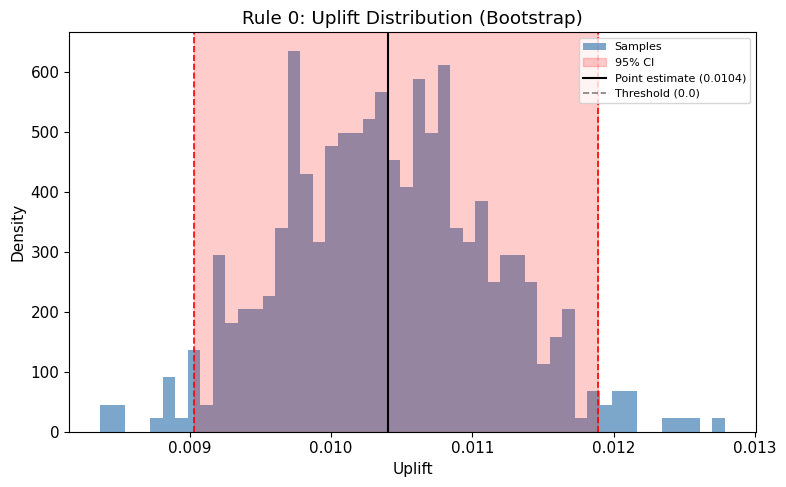

In [12]:
# Bootstrap histogram for the first rule
fig = bootstrap_histogram(results_boot[0], metric="uplift", threshold=0.0)
plt.tight_layout()

### 8.2 Posterior Plot (Bayesian, Single Rule)

The Bayesian posterior plot shows a kernel density estimate (KDE) of the 10,000 Monte Carlo samples drawn from the posterior distribution. Unlike the bootstrap histogram, which represents a *sampling distribution*, this represents our *belief* about the true parameter value after observing the data. The shaded region is the 95% credible interval.

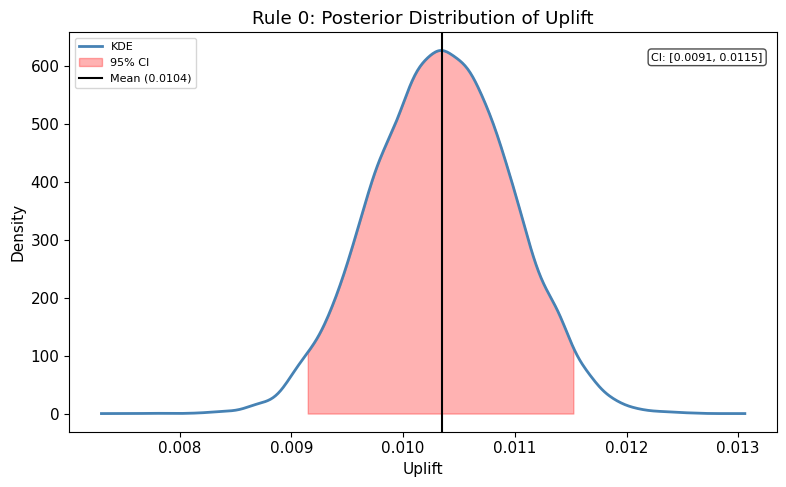

In [13]:
# Bayesian posterior KDE for the first rule
fig = posterior_plot(results_bayes[0], metric="uplift")
plt.tight_layout()

### 8.3 Forest Plot (Bootstrap, All Rules)

A forest plot displays all rules simultaneously, sorted by point estimate. Each row shows the rule index, a point estimate (dot), and the 95% CI (horizontal bar). With `show_categories=True`, rules are color-coded by decision:

- **Green**: Accept — entire CI is above the threshold (significant positive uplift)
- **Red**: Reject — entire CI is below the threshold
- **Orange**: Uncertain — CI crosses the threshold

If more than 30 rules are present, we slice to the first 20 for readability.

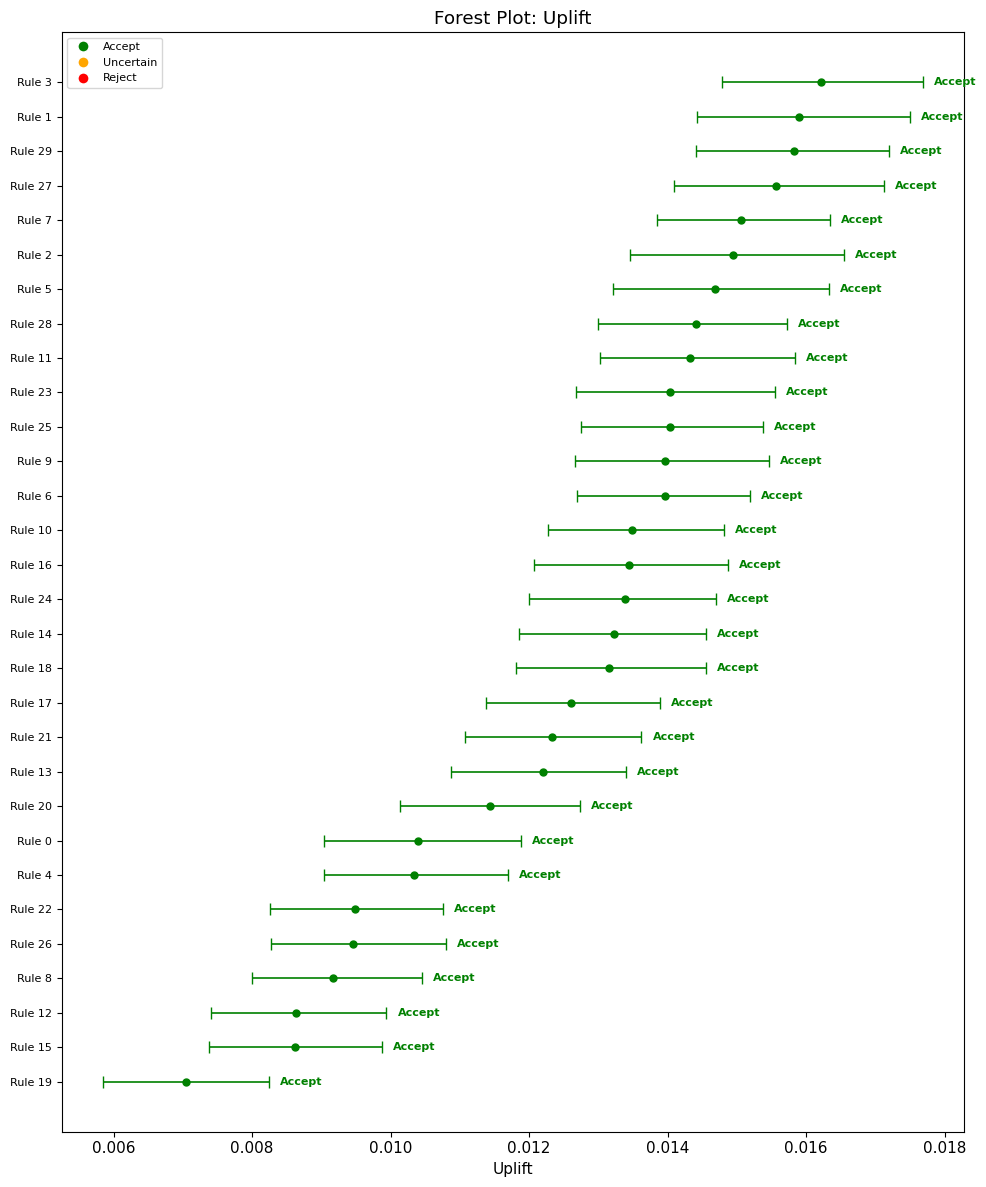

In [14]:
# Slice to first 20 rules if there are many, for visual clarity
boot_for_plot = results_boot[:20] if len(results_boot) > 30 else results_boot

fig = forest_plot(boot_for_plot, metric="uplift", threshold=0.0, show_categories=True)
plt.tight_layout()

### 8.4 Grouped Forest Plot (All Three Methods)

The grouped forest plot overlays Bootstrap, Analytic, and Bayesian CIs for each rule. This is a diagnostic tool: if all three methods produce similar intervals, we can trust the estimates. Divergence typically indicates borderline sample sizes where the normal approximation breaks down.

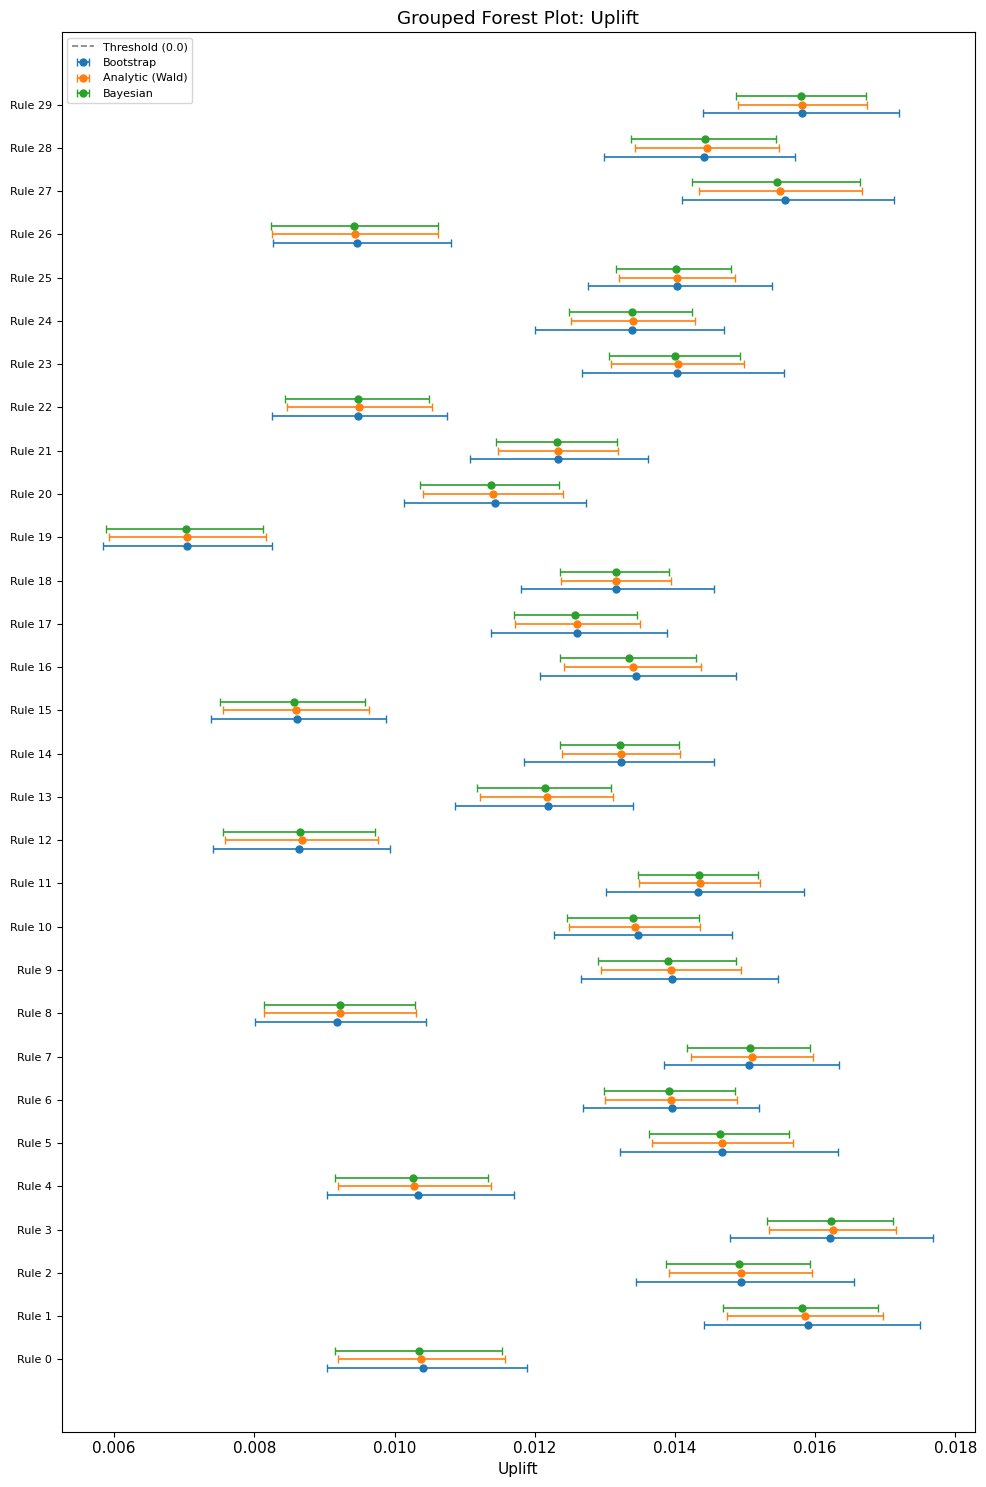

In [15]:
# Limit to the same slice used in the individual forest plot
n_show = min(20, n_rules) if n_rules > 30 else n_rules

fig = grouped_forest_plot(
    {
        "Bootstrap": results_boot[:n_show],
        "Analytic (Wald)": results_anal[:n_show],
        "Bayesian": results_bayes[:n_show],
    },
    metric="uplift",
    threshold=0.0,
)
plt.tight_layout()

## 9. Rule Categorization — Accept / Reject / Uncertain

For deployment decisions, we need a binary (or near-binary) verdict for each rule. The categorization mechanism compares the CI against a threshold:

- **Accept**: the entire CI lies *above* the threshold — we are confident the rule has positive uplift.
- **Reject**: the entire CI lies *below* the threshold — we are confident the rule is not effective.
- **Uncertain**: the CI *straddles* the threshold — more data or a wider study is needed.

This three-valued verdict is more informative than a p-value: it distinguishes rules where the evidence is conclusively negative from those where the sample was simply insufficient.

In [16]:
# Recompute bootstrap CIs with an explicit threshold for categorization
results_cat = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="uplift",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Uplift':>10} | {'95% CI':>28} | {'Category':>12}")
print("-" * 70)
for r in results_cat:
    cat = r.category.value if r.category else "N/A"
    print(
        f"  {r.rule_index:>4} | {r.uplift_point:>10.6f} | "
        f"[{r.uplift_ci_lower:>10.6f}, {r.uplift_ci_upper:>10.6f}] | {cat:>12}"
    )

# Summary
from collections import Counter
category_counts = Counter(
    r.category.value for r in results_cat if r.category is not None
)
print(f"\nCategorization summary: {dict(category_counts)}")

  Rule |     Uplift |                       95% CI |     Category
----------------------------------------------------------------------
     0 |   0.010400 | [  0.009034,   0.011887] |       accept
     1 |   0.015895 | [  0.014420,   0.017495] |       accept
     2 |   0.014944 | [  0.013450,   0.016550] |       accept
     3 |   0.016213 | [  0.014784,   0.017689] |       accept
     4 |   0.010333 | [  0.009036,   0.011698] |       accept
     5 |   0.014678 | [  0.013217,   0.016329] |       accept
     6 |   0.013960 | [  0.012684,   0.015193] |       accept
     7 |   0.015053 | [  0.013840,   0.016346] |       accept
     8 |   0.009175 | [  0.008005,   0.010456] |       accept
     9 |   0.013964 | [  0.012667,   0.015466] |       accept
    10 |   0.013480 | [  0.012276,   0.014809] |       accept
    11 |   0.014325 | [  0.013021,   0.015841] |       accept
    12 |   0.008640 | [  0.007409,   0.009939] |       accept
    13 |   0.012195 | [  0.010870,   0.013397] |       ac

## 10. Utility-Aware Analysis

Statistical uplift measures the change in the probability of a favorable outcome. The **realistic rule gain** translates this into an economic quantity by combining:

1. The intrinsic utility of each outcome state (e.g., +1000 TWD for non-default, -5000 TWD for default)
2. The cost or benefit of the recommended transition (e.g., -200 TWD to raise credit limit from low to medium)

A rule with positive uplift but negative realistic gain should not be deployed — the intervention cost exceeds the expected benefit.

In [17]:
# Compute bootstrap CIs for realistic rule gain with categorization threshold at 0
results_gain = ar.confidence_intervals(
    data,
    method="bootstrap",
    confidence_level=0.95,
    threshold=0.0,
    metric="realistic_rule_gain",
    n_bootstrap=500,
    random_state=42,
)

print(f"{'Rule':>6} | {'Gain (TWD)':>12} | {'95% CI':>30} | {'Category':>12}")
print("-" * 75)
for r in results_gain:
    if r.realistic_rule_gain_point is not None:
        cat = r.category.value if r.category else "N/A"
        print(
            f"  {r.rule_index:>4} | {r.realistic_rule_gain_point:>12.2f} | "
            f"[{r.realistic_rule_gain_ci_lower:>12.2f}, {r.realistic_rule_gain_ci_upper:>12.2f}] | {cat:>12}"
        )

  Rule |   Gain (TWD) |                         95% CI |     Category
---------------------------------------------------------------------------
     0 |      2332.01 | [     2065.01,      2579.71] |       accept
     1 |      3610.89 | [     3384.80,      3869.75] |       accept
     2 |      3465.63 | [     3251.56,      3681.82] |       accept
     3 |      3720.91 | [     3506.98,      3919.76] |       accept
     4 |      2501.78 | [     2235.17,      2771.09] |       accept
     5 |      3615.64 | [     3375.95,      3839.00] |       accept
     6 |      3495.37 | [     3285.04,      3718.69] |       accept
     7 |      3740.55 | [     3543.06,      3935.21] |       accept
     8 |      2296.03 | [     2032.88,      2549.84] |       accept
     9 |      3524.33 | [     3284.77,      3773.11] |       accept
    10 |      3469.04 | [     3262.52,      3680.97] |       accept
    11 |      3654.98 | [     3432.50,      3876.73] |       accept
    12 |      2307.57 | [     2034.38,

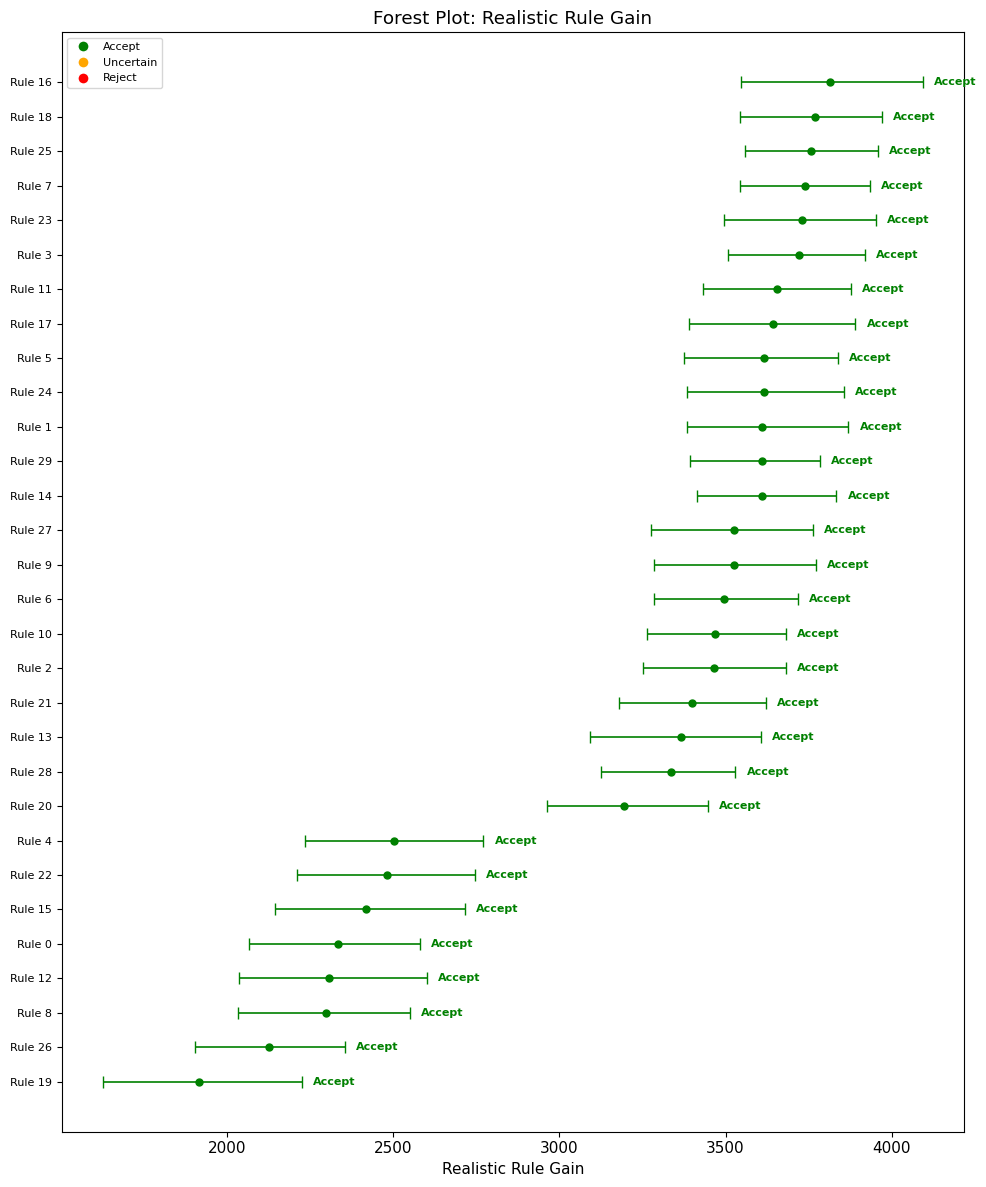

In [18]:
# Forest plot for realistic rule gain with Accept/Reject/Uncertain coloring
gain_for_plot = results_gain[:20] if len(results_gain) > 30 else results_gain

fig = forest_plot(gain_for_plot, metric="realistic_rule_gain", threshold=0.0, show_categories=True)
plt.tight_layout()

## 11. Method Comparison

We now compare all three CI methods on the `realistic_rule_gain` metric. The grouped forest plot provides a visual comparison, and the DataFrame below quantifies the differences in CI width and point estimates across methods.

In [19]:
# Compute gain CIs with all three methods
gain_boot = ar.confidence_intervals(
    data, method="bootstrap", n_bootstrap=500, random_state=42
)
gain_anal = ar.confidence_intervals(
    data, method="analytic"
)
gain_bayes = ar.confidence_intervals(
    data, method="bayesian", n_mc=10000, random_state=42
)

print(f"Rules computed — Bootstrap: {len(gain_boot)}, Analytic: {len(gain_anal)}, Bayesian: {len(gain_bayes)}")

Rules computed — Bootstrap: 30, Analytic: 30, Bayesian: 30


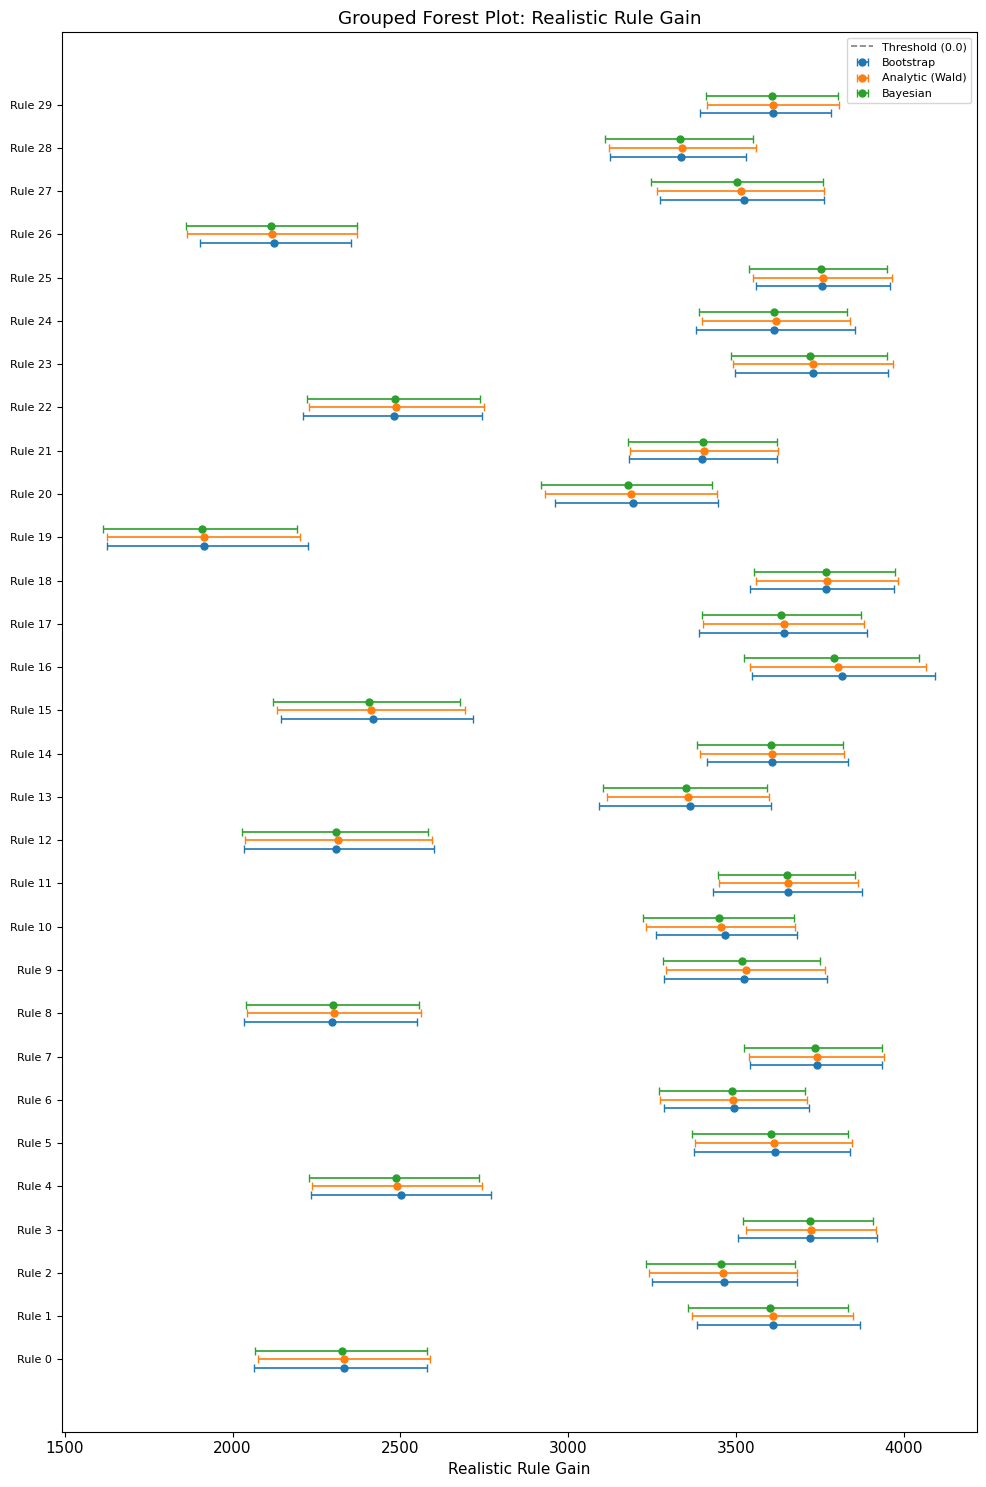

In [20]:
# Grouped forest plot comparing all three methods on realistic rule gain
n_show_gain = min(20, n_rules) if n_rules > 30 else n_rules

fig = grouped_forest_plot(
    {
        "Bootstrap": gain_boot[:n_show_gain],
        "Analytic (Wald)": gain_anal[:n_show_gain],
        "Bayesian": gain_bayes[:n_show_gain],
    },
    metric="realistic_rule_gain",
    threshold=0.0,
)
plt.tight_layout()

In [21]:
# Build a side-by-side comparison DataFrame
rows = []
for method_name, results in [
    ("Bootstrap", gain_boot),
    ("Analytic", gain_anal),
    ("Bayesian", gain_bayes),
]:
    for r in results:
        row = {
            "Rule": r.rule_index,
            "Method": method_name,
            "Uplift": round(r.uplift_point, 6),
            "Uplift CI Lower": round(r.uplift_ci_lower, 6),
            "Uplift CI Upper": round(r.uplift_ci_upper, 6),
            "Uplift CI Width": round(r.uplift_ci_upper - r.uplift_ci_lower, 6),
        }
        if r.realistic_rule_gain_point is not None:
            row["Gain"] = round(r.realistic_rule_gain_point, 2)
            row["Gain CI Lower"] = round(r.realistic_rule_gain_ci_lower, 2)
            row["Gain CI Upper"] = round(r.realistic_rule_gain_ci_upper, 2)
            row["Gain CI Width"] = round(
                r.realistic_rule_gain_ci_upper - r.realistic_rule_gain_ci_lower, 2
            )
        rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values(["Rule", "Method"]).reset_index(drop=True)
print(f"Comparison table: {comparison_df.shape[0]} rows")
comparison_df

Comparison table: 90 rows


,Rule,Method,Uplift,Uplift CI Lower,Uplift CI Upper,Uplift CI Width,Gain,Gain CI Lower,Gain CI Upper,Gain CI Width
0,0,Analytic,0.010381,0.009192,0.011571,0.002379,2332.51,2076.73,2588.29,511.56
1,0,Bayesian,0.010350,0.009147,0.011527,0.002380,2325.91,2066.99,2578.93,511.93
2,0,Bootstrap,0.010400,0.009034,0.011887,0.002853,2332.01,2065.01,2579.71,514.70
3,1,Analytic,0.015854,0.014740,0.016969,0.002228,3609.55,3369.97,3849.14,479.18
4,1,Bayesian,0.015812,0.014683,0.016898,0.002215,3600.44,3357.57,3833.95,476.39
...,...,...,...,...,...,...,...,...,...,...
85,28,Bayesian,0.014428,0.013373,0.015436,0.002063,3334.36,3108.83,3549.77,440.95
86,28,Bootstrap,0.014412,0.012991,0.015716,0.002725,3335.12,3125.06,3529.56,404.49
87,29,Analytic,0.015820,0.014901,0.016739,0.001838,3611.90,3415.41,3808.40,392.99
88,29,Bayesian,0.015802,0.014879,0.016721,0.001842,3608.07,3410.71,3804.57,393.87


## 12. Summary

In this notebook we applied the full action rules mining and confidence interval workflow to the **Taiwan Credit Card Default dataset**.

**Key findings:**

- Mining with `min_stable_attributes=2`, `min_flexible_attributes=1`, support thresholds of 450, and confidence thresholds of 0.6 yields approximately 30 interpretable rules on a 30,000-row dataset.
- **Stable attributes** (sex, education, marriage status, age) segment the client population into groups where the rule conditions are relevant. **Flexible attributes** (credit limit tier, recent repayment status, latest payment amount) represent the three actionable dimensions recommended by each rule.
- **Bootstrap CIs** provide reliable, assumption-free intervals at the cost of computation time. With 30,000 rows the bootstrap is still fast enough for practical use.
- **Analytic (Wald) CIs** run near-instantaneously and produce intervals close to the bootstrap results, confirming that the sample size is large enough for the normal approximation to hold.
- **Bayesian credible intervals** align well with the other two methods, providing an additional perspective through the lens of posterior probability.
- **Rule categorization** (Accept / Reject / Uncertain) gives practitioners a clear deployment signal without requiring statistical expertise.
- **Utility-aware analysis** shows that not all statistically significant rules are economically worthwhile. Rules involving credit limit increases carry an underwriting cost; whether the expected default reduction outweighs that cost depends on the specific client segment.

**Credit risk interpretation:**

Rules with high positive uplift and positive realistic gain represent segments where targeted interventions — such as encouraging timely payments, adjusting credit limits, or proactive customer outreach — are both statistically supported and economically justified. The Accept/Reject/Uncertain framework helps risk managers prioritize which interventions to pilot first.

**Next steps:**
- Increase `n_bootstrap` to 1000+ for production-quality CIs.
- Refine utility tables with actual business cost estimates.
- Use the `output_json_path` CLI argument to export rules and CIs for downstream consumption.
- Explore the effect of varying `min_undesired_confidence` and `min_desired_confidence` thresholds on the Accept/Uncertain ratio.